# Week 9 - Gradient Boost

For Week 9, include concepts such as:
- Gradient Boost
- Learning Rate, n_estimators, max_depth

In [49]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

random_seed = 42

In [7]:
#Removing Frame
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True

Data Import

In [10]:
d19 = pd.read_csv('Flight_delay_2019H1.csv', low_memory = False)
d19.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


<h3>Data Dictionary</h3>

- DayOfWeek → 1 (Monday) - 7 (Sunday)
- Date → Scheduled date
- DepTime → Actual departure time (local, hhmm)
- ArrTime → Actual arrival time (local, hhmm)
- CRSArrTime → Scheduled arrival time (local, hhmm)
- UniqueCarrier → Unique carrier code
- Airline → Airline company
- FlightNum → flight number
- TailNum → plane tail number
- ActualElapsedTime → Actual time an airplane spends in the air(in minutes) with TaxiIn/Out
- CRSElapsedTime → CRS Elapsed Time of Flight (estimated elapse time), in minutes
- AirTime → Flight Time (in minutes)
- ArrDelay → Difference in minutes between scheduled and actual arrival time
- Origin → Origin IATA(International Air Transport Association) airport code
- Org_Airport → Origin Airport Name
- Dest → Destination IATA code
- Dest_Airport → Destination Airport Name
- Distance → Distance between airports (miles)
- TaxiIn → Wheels down and arrival at the destination airport gate, in minutes
- TaxiOut → The time elapsed between departure from the origin airport gate and wheels off, in minutes
- Cancelled → Was the flight canceled?
- CancellationCode → Reason for cancellation
- Diverted → 1 = yes, 0 = no
- CarrierDelay → Flight delay due to carrier(e.g. maintenance or crew problems, aircraft cleaning, fueling, etc), 0 = No, yes = (in minutes)
- WeatherDelay → Flight delay due to weather, 0 = No, yes = (in minutes)
- NASDelay → Flight delay by NSA(National Aviation System), 0 = No, yes = (in minutes)
- SecurityDelay → Flight delay by this reason, 0 = No, yes = (in minutes)
- LateAircraftDelay → Flight delay by this reason, 0 = No, yes = (in minutes)

In [14]:
all19 = d19.copy()

<h3>Preprocessing</h3>

In [17]:
#get rid of the null values

f19 = all19.dropna()

In [19]:
f19 = f19.drop(['Cancelled', 'CancellationCode'], axis = 1)

<h3>Adjusting the Date Variable</h3>

In [22]:
f19['Date'] = pd.to_datetime(f19['Date'], format = '%d-%m-%Y')

In [24]:
number19 = f19.select_dtypes(include=np.number).drop(['Diverted'], axis = 1) #creating df of numeric columns only to run correlation matrix

In [26]:
corrs = number19.corr()

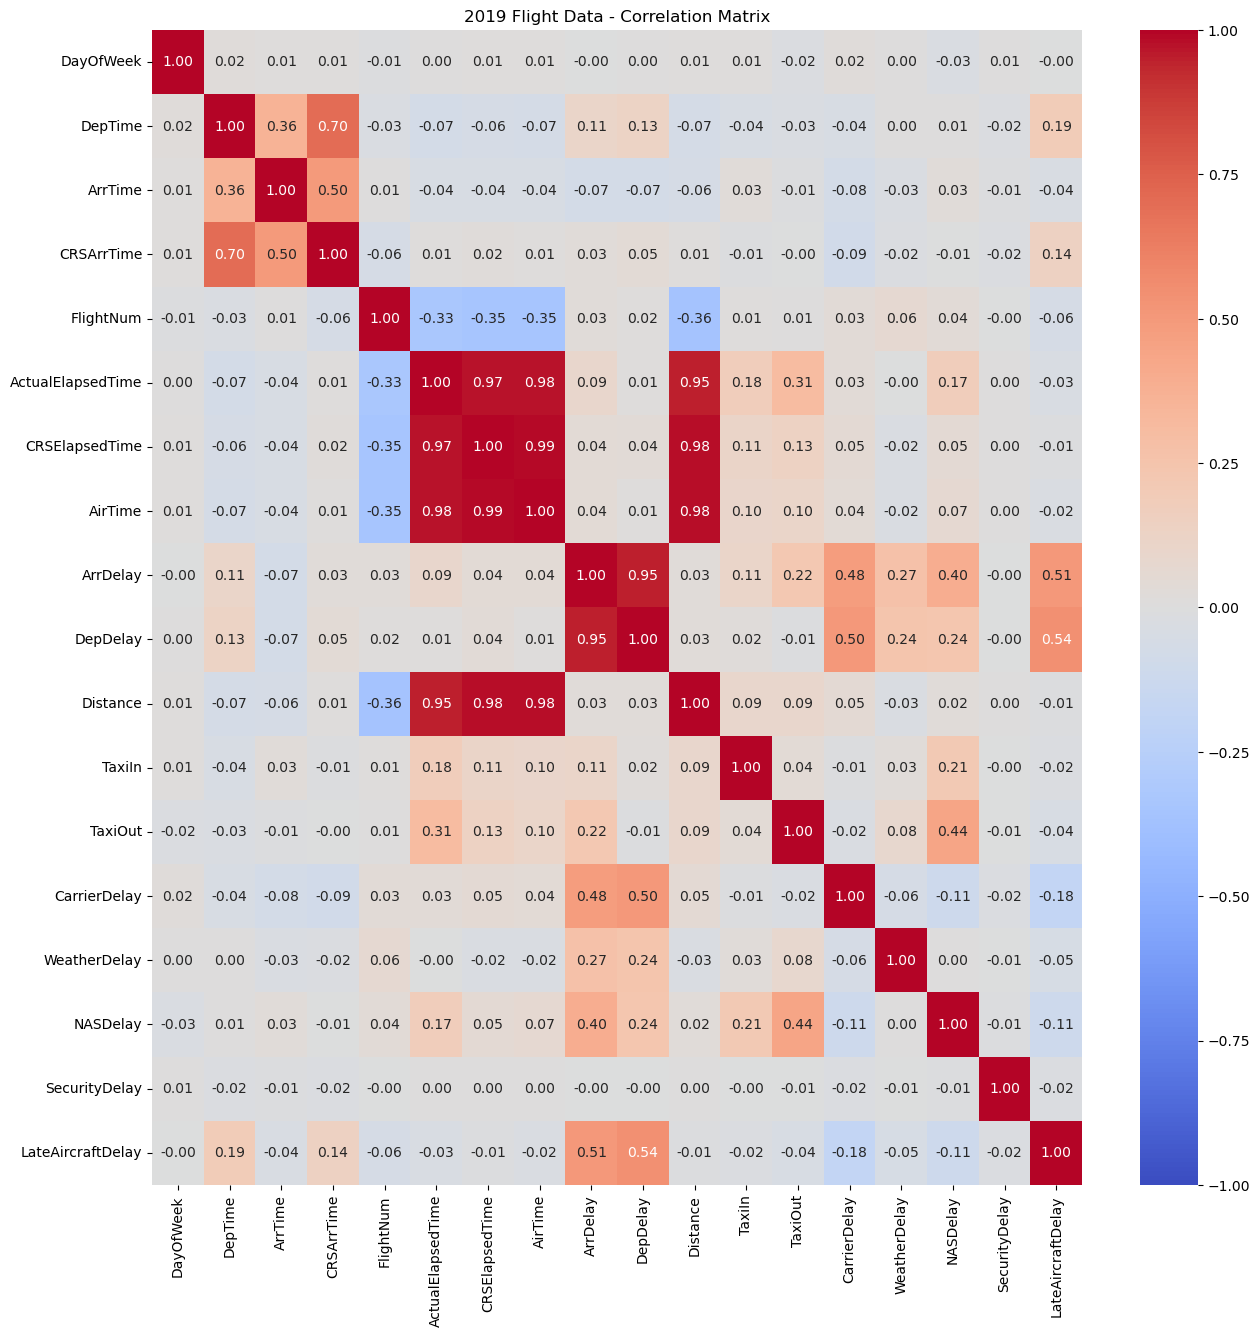

In [28]:
plt.figure(figsize=(15, 15))

# Making a heatmap
sns.heatmap(corrs,
            annot=True,     # Annotate each cell with the correlation value
            fmt=".2f",      # Set the annotation format to two decimal places
            cmap='coolwarm',# Choose a divergent color map
            vmin=-1, vmax=1,# Ensure the color scale ranges from -1 to 1
            center=0        # Center the color map at 0
           )

# Display the plot
plt.title('2019 Flight Data - Correlation Matrix')
plt.show()

<h3>Gradient Boost</h3>

In [31]:
#standard scaling the numerical data

sc = StandardScaler()

sc19 = sc.fit_transform(number19)
df_scaled = pd.DataFrame(sc19, columns=number19.columns)
df_scaled.head()

,DayOfWeek,DepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0.004507,0.584211,0.583753,0.583732,0.996963,-0.609590,-0.583439,-0.459369,-0.471963,-0.419299,-0.419948,-0.681238,-0.597744,-0.390382,-0.161092,-0.432646,-0.043374,0.129965
1,0.004507,0.822991,0.717269,0.615905,-0.894996,1.414908,1.652383,1.722125,-0.068092,0.170411,1.462134,-0.681238,-0.793451,-0.186718,-0.161092,-0.432646,-0.043374,0.499698
2,0.004507,0.175189,0.388614,0.154751,-0.437953,-0.191194,0.045386,-0.031625,0.335779,0.652901,0.127535,-0.141305,-0.728215,-0.237634,-0.161092,-0.432646,-0.043374,1.115921
3,0.004507,-0.249309,0.037707,-0.059740,-0.802922,1.252948,1.512644,1.479737,-0.805595,-0.544389,1.283721,0.038673,-0.728215,-0.364924,-0.161092,-0.432646,-0.043374,-0.363013
4,0.004507,-0.534518,-0.157432,-0.306404,-1.175101,-0.164200,0.045386,0.011150,-0.788036,-0.526519,0.145026,-0.501260,-0.662980,-0.441298,-0.161092,-0.432646,-0.043374,-0.264418


In [33]:
#setting our inputs to be the foward-selected variables from Week 3

fwd_vars = ['TaxiOut', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'LateAircraftDelay']

In [35]:
#set our x_train and y_train (fwd selected vars for X, departure delay time for y)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_scaled[fwd_vars], df_scaled.DepDelay,
                                                    test_size=0.25, random_state=random_seed)

In [37]:
len(X_test)

120474

In [51]:
#performing cross_validation to find optimal K

from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold

repeated_cv = RepeatedKFold(n_splits     = 3, 
                            n_repeats    = 1,
                            random_state = random_seed
                           )     

# Define the parameter grid
param_dist = {
     'n_estimators': range(100, 110),
     'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2], 
     'max_depth' : range(1, 6),
     'min_samples_leaf': range(1, 6)
}

# Setup the regressor
gb = GradientBoostingRegressor()

# Perform cross validation
ran_search = RandomizedSearchCV(gb, param_dist, cv=repeated_cv,
                           scoring='neg_root_mean_squared_error', 
                           n_jobs = -1,
                           verbose = 1)

ran_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=RepeatedKFold(n_repeats=1, n_splits=3, random_state=42),
                   estimator=GradientBoostingRegressor(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2],
                                        'max_depth': range(1, 6),
                                        'min_samples_leaf': range(1, 6),
                                        'n_estimators': range(100, 110)},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [55]:
results = pd.DataFrame(ran_search.cv_results_)

# Convert negative RMSE to positive
results['mean_test_RMSE'] = -results['mean_test_score']
results = results.sort_values(by = 'mean_test_RMSE')
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_leaf,param_max_depth,param_learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_test_RMSE
3,22.848142,0.307850,0.208171,0.017647,101,3,5,0.15,"{'n_estimators': 101, 'min_samples_leaf': 3, '...",-0.169253,-0.163844,-0.173283,-0.168793,0.003867,1,0.168793
9,15.717874,1.037761,0.159158,0.007499,103,3,5,0.10,"{'n_estimators': 103, 'min_samples_leaf': 3, '...",-0.170018,-0.165449,-0.173789,-0.169752,0.003410,2,0.169752
0,22.692837,0.205968,0.185919,0.017455,104,1,5,0.20,"{'n_estimators': 104, 'min_samples_leaf': 1, '...",-0.169223,-0.164841,-0.175579,-0.169881,0.004409,3,0.169881
4,24.364979,0.204112,0.238651,0.024228,108,5,5,0.10,"{'n_estimators': 108, 'min_samples_leaf': 5, '...",-0.171449,-0.167438,-0.173565,-0.170818,0.002541,4,0.170818
5,18.593958,0.175781,0.145245,0.014527,102,5,4,0.20,"{'n_estimators': 102, 'min_samples_leaf': 5, '...",-0.171673,-0.169727,-0.172925,-0.171442,0.001315,5,0.171442
6,10.191184,0.019924,0.075916,0.017805,108,2,2,0.10,"{'n_estimators': 108, 'min_samples_leaf': 2, '...",-0.227475,-0.226101,-0.231011,-0.228196,0.002068,6,0.228196
1,14.007407,0.153890,0.128812,0.005411,109,1,3,0.05,"{'n_estimators': 109, 'min_samples_leaf': 1, '...",-0.241046,-0.237249,-0.242329,-0.240208,0.002157,7,0.240208
7,13.394799,0.216891,0.093160,0.005890,100,5,3,0.05,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",-0.254123,-0.250152,-0.254748,-0.253008,0.002035,8,0.253008
2,4.607280,0.074957,0.040851,0.008366,102,5,1,0.10,"{'n_estimators': 102, 'min_samples_leaf': 5, '...",-0.403082,-0.399902,-0.403825,-0.402269,0.001701,9,0.402269
8,12.281100,0.734135,0.087075,0.016585,104,3,3,0.01,"{'n_estimators': 104, 'min_samples_leaf': 3, '...",-0.599301,-0.588484,-0.596689,-0.594825,0.004608,10,0.594825


In [59]:
# Output the best K
print(f"Optimal Parameters: {ran_search.best_params_}")

Optimal Parameters: {'n_estimators': 101, 'min_samples_leaf': 3, 'max_depth': 5, 'learning_rate': 0.15}


In [61]:
final_gb = GradientBoostingRegressor(n_estimators = 101,
                                    min_samples_leaf = 3,
                                    max_depth = 5,
                                    learning_rate = 0.15)
final_gb.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.15, max_depth=5, min_samples_leaf=3,
                          n_estimators=101)

In [63]:
y_preds = final_gb.predict(X_test)
test_RMSE = root_mean_squared_error(y_test, y_preds)
print('RMSE of our optimized GB on the test set:', f"{test_RMSE:.3f}")

RMSE of our optimized GB on the test set: 0.162


<h2>Conclusions</h2>

- After standard scaling the data, we ran a grid search on the 2019 H1 data (5 forward-selected variables: 'TaxiOut', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'LateAircraftDelay') with Repeated K-Fold cross-validation to determine the optimal number of learning_rate, n_estimators, and max_depth for the GradientBoostingRegressor model. The HistGradientBoostingRegressor model handles larger datasets faster, but we can't tune the n_estimators hyperparameter if we use that model. So we'll keep it simple. The best set of parameters gave a mean CV RMSE of 0.1687, which is probably the best we've seen so far (the regular random forest being the best model we had is coming into question...)
- Regularization is done by tuning the "min_samples_leaf" parameter. We got an optimal value at 3
- After determining the optimal K, we ran a final GradientBoostingRegressorModel with our optimized hyperparameters (learning_rate=0.15, max_depth=5, min_samples_leaf=3, n_estimators=101). The test RMSE came out to 0.162, a little better than our CV RMSE (but not so drastic as to suggest overfitting) and the best we've seen so far